<a href="https://colab.research.google.com/github/OkktaDan/CCMACLRL_EXERCISES_COM231/blob/main/Exercises/Exercises_6/Exercise6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercise 6: Choosing the best performing model on a dataset

Instructions:

- Use the Dataset File to train your model
- Use the Test File to generate your results
- Use the Sample Submission file to generate the same format
- Use all Regression models

Submit your results to:
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview



In [934]:
import pandas as pd
import seaborn as sns
import numpy as np

from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

## Dataset File

In [935]:
train_data = 'https://github.com/robitussin/CCMACLRL_EXERCISES/blob/3fd7d51ffd17863598ac3f44eeefc558171a5b73/dataset/house-prices-advanced-regression-techniques/train.csv?raw=true'
df = pd.read_csv(train_data)

## Test File

In [936]:
test_url = 'https://github.com/robitussin/CCMACLRL_EXERCISES/blob/3fd7d51ffd17863598ac3f44eeefc558171a5b73/dataset/house-prices-advanced-regression-techniques/test.csv?raw=true'
dt=pd.read_csv(test_url)

In [937]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

## Sample Submission File

In [938]:
sample_submission_url ='https://github.com/robitussin/CCMACLRL_EXERCISES/blob/3fd7d51ffd17863598ac3f44eeefc558171a5b73/dataset/house-prices-advanced-regression-techniques/sample_submission.csv?raw=true'

sf=pd.read_csv(sample_submission_url)

In [939]:
sf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         1459 non-null   int64  
 1   SalePrice  1459 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 22.9 KB


In [940]:
df.head(100)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,60,RL,NaN,9765,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,NaN,Shed,480,4,2009,WD,Normal,185000
96,97,20,RL,78.0,10264,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2006,WD,Normal,214000
97,98,20,RL,73.0,10921,Pave,NaN,Reg,HLS,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,94750
98,99,30,RL,85.0,10625,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,400,5,2010,COD,Abnorml,83000


In [941]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [942]:
column=['LotFrontage', 'Street', 'Utilities', 'PoolArea', 'Id']
df = df.drop(columns=column, axis=1)

In [943]:
counts = df['Alley'].value_counts()
for value, count in counts.items():
    print(f"Value: {value}, Count: {count}")

Value: Grvl, Count: 50
Value: Pave, Count: 41


Convert all non-numerical values to numerical

In [944]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in  df.columns:
  if df[col].dtype == 'object':
    series = df[col]
    df[col] = pd.Series(le.fit_transform(series[series.notnull()]), index=series[series.notnull()].index)
  df[col].fillna(df[col].mean(), inplace=True)
  df[col] = df[col].astype(int)

df.head(100)


/tmp/ipython-input-1503501391.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-1503501391.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,MSSubClass,MSZoning,LotArea,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,ScreenPorch,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,8450,0,3,3,4,0,5,2,...,0,1,1,1,0,2,2008,8,4,208500
1,20,3,9600,0,3,3,2,0,24,1,...,0,1,1,1,0,5,2007,8,4,181500
2,60,3,11250,0,0,3,4,0,5,2,...,0,1,1,1,0,9,2008,8,4,223500
3,70,3,9550,0,0,3,0,0,6,2,...,0,1,1,1,0,2,2006,8,0,140000
4,60,3,14260,0,0,3,2,0,15,2,...,0,1,1,1,0,12,2008,8,4,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,60,3,9765,0,1,3,0,0,8,2,...,0,1,1,2,480,4,2009,8,4,185000
96,20,3,10264,0,0,3,4,0,5,2,...,0,1,1,1,0,8,2006,8,4,214000
97,20,3,10921,0,3,1,4,0,7,2,...,0,1,1,1,0,5,2007,8,4,94750
98,30,3,10625,0,3,3,0,0,7,2,...,0,1,1,2,400,5,2010,0,0,83000


In [945]:
list_col = df.columns
list_col.drop('SalePrice')

x = list_col
y = df['SalePrice']

In [946]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('SalePrice', axis=1), df['SalePrice'], test_size=0.3, random_state=1)
score_list = {}

## 1. Train a KNN Regressor

In [947]:
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score

In [948]:
KNN = KNeighborsRegressor(n_neighbors=3)
KNN.fit(x_train, y_train)
rms = root_mean_squared_error(y_test, KNN.predict(x_test))
score_list['KNN'] = rms
print(rms)

52306.51219789438


- Perform cross validation

In [949]:
scores = cross_val_score(KNN, x_train, y_train, cv=5)
print(scores)

[0.60045057 0.63834697 0.59253388 0.67042911 0.65117354]


## 2. Train a SVM Regression

In [950]:
svr = SVR(kernel='linear')
svr.fit(x_train, y_train)
rms = root_mean_squared_error(y_test, svr.predict(x_test))
score_list['SVR'] = rms
print(rms)

37256.025539221955


- Perform cross validation

In [951]:
scores = cross_val_score(svr, x_train, y_train, cv=5)
print(scores)

[0.49473367 0.76167687 0.68970982 0.78434975 0.79230933]


## 3. Train a Decision Tree Regression

In [952]:
dtr = DecisionTreeRegressor()
dtr.fit(x_train, y_train)
rms = root_mean_squared_error(y_test, dtr.predict(x_test))
score_list['DTR'] = rms
print(rms)

36116.21313676425


- Perform cross validation

In [953]:
scores = cross_val_score(dtr, x_train, y_train, cv=5)
print(scores)

[0.46773184 0.60303228 0.65252446 0.74848036 0.78056196]


## 4. Train a Random Forest Regression

In [954]:
rfc = RandomForestRegressor()
model = rfc.fit(x_train, y_train)
rms = root_mean_squared_error(y_test, rfc.predict(x_test))
score_list['RFC'] = rms
print(rms)

25488.31288170767


## 5. Compare all the performance of all regression models

In [955]:
score_list = list(score_list.items())
for alg, score in score_list:
  print(f'{alg}: {score}')

KNN: 52306.51219789438
SVR: 37256.025539221955
DTR: 36116.21313676425
RFC: 25488.31288170767


Text(0, 0.5, 'Feature')

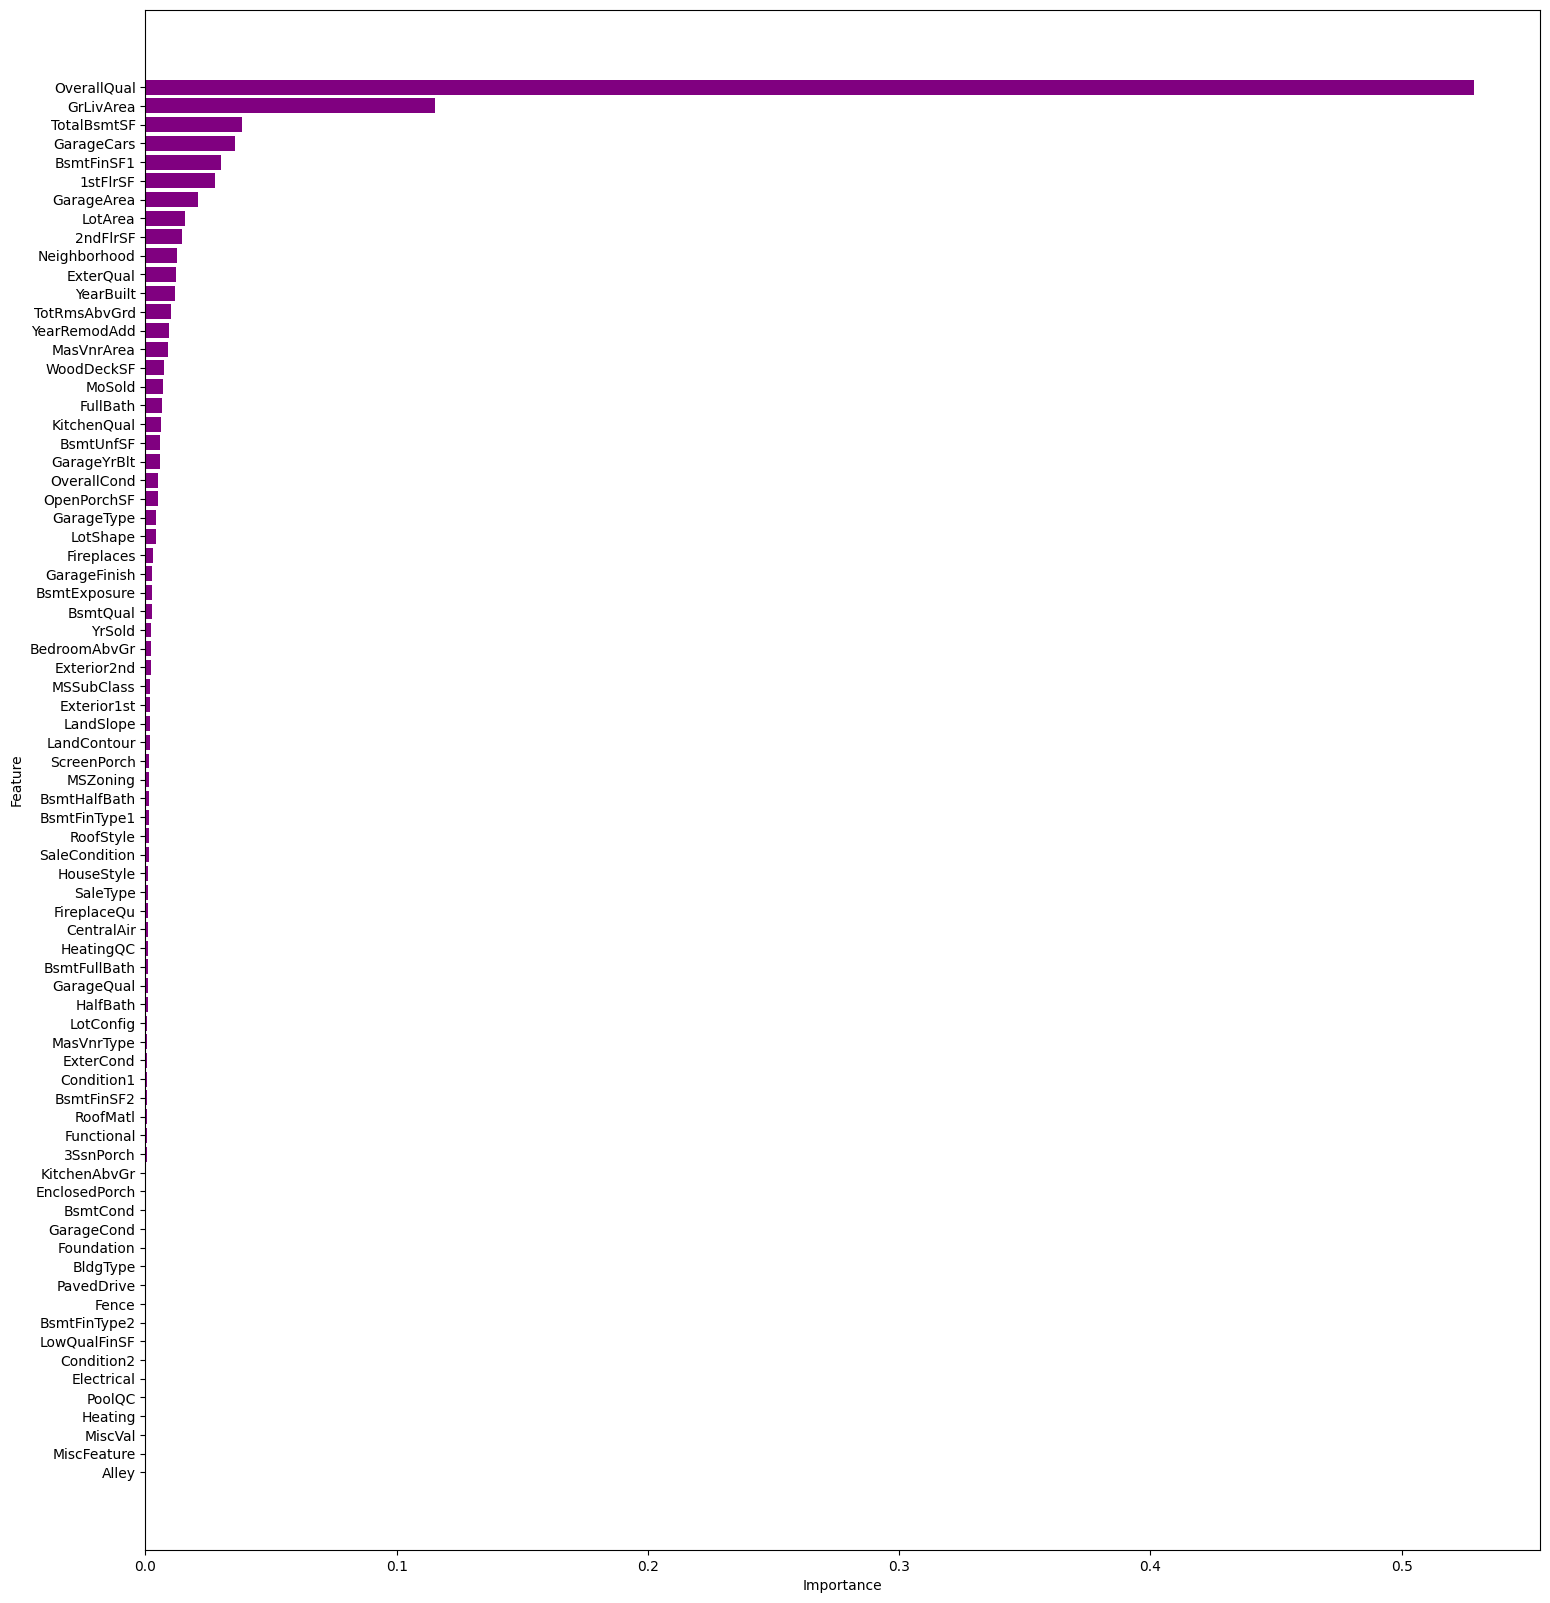

In [956]:
feature_importance = pd.DataFrame({'Feature': x_train.columns, 'rfc': model.feature_importances_})
feature_importance = feature_importance.sort_values(by='rfc', ascending=True)
index = np.arange(len(feature_importance))
fig, ax = plt.subplots(figsize=(18, 20))
rfc_feature = ax.barh(index, feature_importance['rfc'], color='purple', label='Random Forest')
ax.set_yticks(index)
ax.set_yticklabels(feature_importance['Feature'])
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')


## 6. Generate Submission File

Choose the model that has the best performance to generate a submission file.

In [957]:

dt = dt.drop(columns=['LotFrontage', 'Id', 'PoolArea', 'Street', 'Utilities'], axis=1)

for col in dt.columns:
  if dt[col].dtype == 'object':
    series = dt[col]
    dt[col] = pd.Series(le.fit_transform(series[series.notnull()]), index=series[series.notnull()].index)
  dt[col].fillna(dt[col].mean(), inplace=True)
  dt[col] = dt[col].astype(int)

y_pred = model.predict(dt)

# Create a submission DataFrame
submission_df = pd.DataFrame({
    'Id': id,
    'SalePrice': y_pred
})

# Save the submission DataFrame to a CSV file
submission_df.to_csv('submission_file.csv', index=False)
print("Submission file created: submission_file.csv")

Submission file created: submission_file.csv


/tmp/ipython-input-3087741216.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dt[col].fillna(dt[col].mean(), inplace=True)
/tmp/ipython-input-3087741216.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 